# Домашняя работа #1
## Максимов Павел Александрович

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import copy

## 1. Загрузка и предобработка данных MNIST

In [3]:
import platform

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используемое устройство (CUDA): {device}")
    print(f"Название GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Используемое устройство (Apple Silicon): {device}")
else:
    device = torch.device("cpu")
    print(f"Используемое устройство (CPU): {device}")
    print(f"Платформа: {platform.system()} {platform.machine()}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

batch_size = 64
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")
print(f"Размер батча: {batch_size}")

Используемое устройство (Apple Silicon): mps
Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Размер обучающей выборки: 60000
Размер тестовой выборки: 10000
Размер батча: 64


## 2. Создание нейронной сети

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        
        x = x.view(-1, 128 * 3 * 3)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


## Расчет выходной размерности карты признаков

Формула для расчета размера выхода после свертки с padding и pooling:

$$W_{out} = \left\lfloor \frac{W_{in} + 2P - K}{S} \right\rfloor + 1$$

где:
- $W_{in}$ - размер входа
- $P$ - padding
- $K$ - kernel_size
- $S$ - stride

Формула для MaxPooling (kernel_size=2 и stride=2):
$$W_{out} = \left\lfloor \frac{W_{in}}{2} \right\rfloor$$

**Расчет для нашей архитектуры:**

1. **Вход:** $28 \times 28$ (MNIST изображения)

2. **После Conv1 (kernel=3, padding=1, stride=1):**
   $$W_1 = \left\lfloor \frac{28 + 2 \cdot 1 - 3}{1} \right\rfloor + 1 = 28$$
   
3. **После Pool1 (kernel=2, stride=2):**
   $$W_2 = \left\lfloor \frac{28}{2} \right\rfloor = 14$$
   
4. **После Conv2 (kernel=3, padding=1, stride=1):**
   $$W_3 = \left\lfloor \frac{14 + 2 \cdot 1 - 3}{1} \right\rfloor + 1 = 14$$
   
5. **После Pool2 (kernel=2, stride=2):**
   $$W_4 = \left\lfloor \frac{14}{2} \right\rfloor = 7$$
   
6. **После Conv3 (kernel=3, padding=1, stride=1):**
   $$W_5 = \left\lfloor \frac{7 + 2 \cdot 1 - 3}{1} \right\rfloor + 1 = 7$$
   
7. **После Pool3 (kernel=2, stride=2):**
   $$W_6 = \left\lfloor \frac{7}{2} \right\rfloor = 3$$

**Итоговая размерность карты признаков:** $128 \times 3 \times 3 = 1152$ элементов


## 3. Цикл обучения и график обучения


In [13]:
def train_model(model, train_loader, optimizer, criterion, num_epochs, device):
    model.train()
    losses = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        total_batches = len(train_loader)
        progress_bar = tqdm(enumerate(train_loader), total=total_batches, desc=f'Эпоха {epoch+1}/{num_epochs}')
        for batch_idx, (data, target) in progress_bar:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
            progress_bar.set_postfix({'loss': loss.item()})
        epoch_loss = running_loss / total_batches
        losses.append(epoch_loss)
        print(f'Эпоха {epoch+1}/{num_epochs} Loss: {epoch_loss:.4f}')
    
    return losses

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
print("Старт обучения")
losses = train_model(model, train_loader, optimizer, criterion, num_epochs, device)

Старт обучения


Эпоха 1/10:   0%|          | 0/938 [00:00<?, ?it/s]

Эпоха 1/10: 100%|██████████| 938/938 [00:14<00:00, 64.53it/s, loss=0.0152] 


Эпоха 1/10 Loss: 0.1586


Эпоха 2/10: 100%|██████████| 938/938 [00:14<00:00, 65.87it/s, loss=0.00154] 


...

Эпоха 8/10 Loss: 0.0100


Эпоха 9/10: 100%|██████████| 938/938 [00:14<00:00, 65.09it/s, loss=0.00435] 


Эпоха 9/10 Loss: 0.0100


Эпоха 10/10: 100%|██████████| 938/938 [00:14<00:00, 65.88it/s, loss=0.00692] 

Эпоха 10/10 Loss: 0.0101


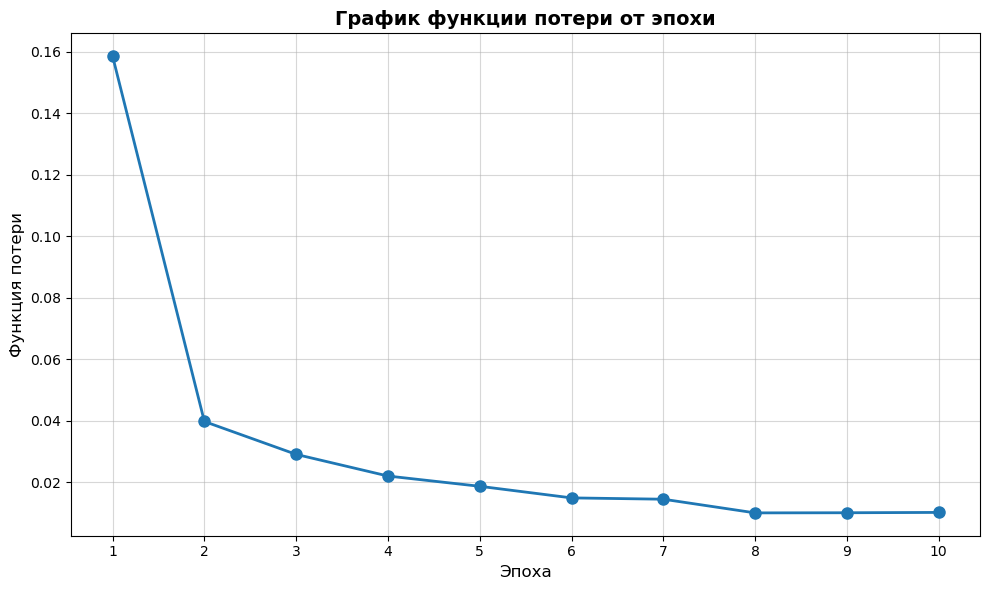

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linewidth=2, markersize=8)
plt.title('График функции потери от эпохи', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Функция потери', fontsize=12)
plt.grid(True, alpha=0.5)
plt.xticks(range(1, num_epochs + 1))
plt.tight_layout()
plt.show()

## 4. Оценка метрик на тестовой выборке


In [15]:
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return accuracy, f1, all_preds, all_labels

accuracy, f1, predictions, true_labels = evaluate_model(model, test_loader, device)

print(f"Accuracy на тестовой выборке: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-score на тестовой выборке: {f1:.4f}")

Accuracy на тестовой выборке: 0.9910 (99.10%)
F1-score на тестовой выборке: 0.9910


## 5. 10 случайных тестовых примеров

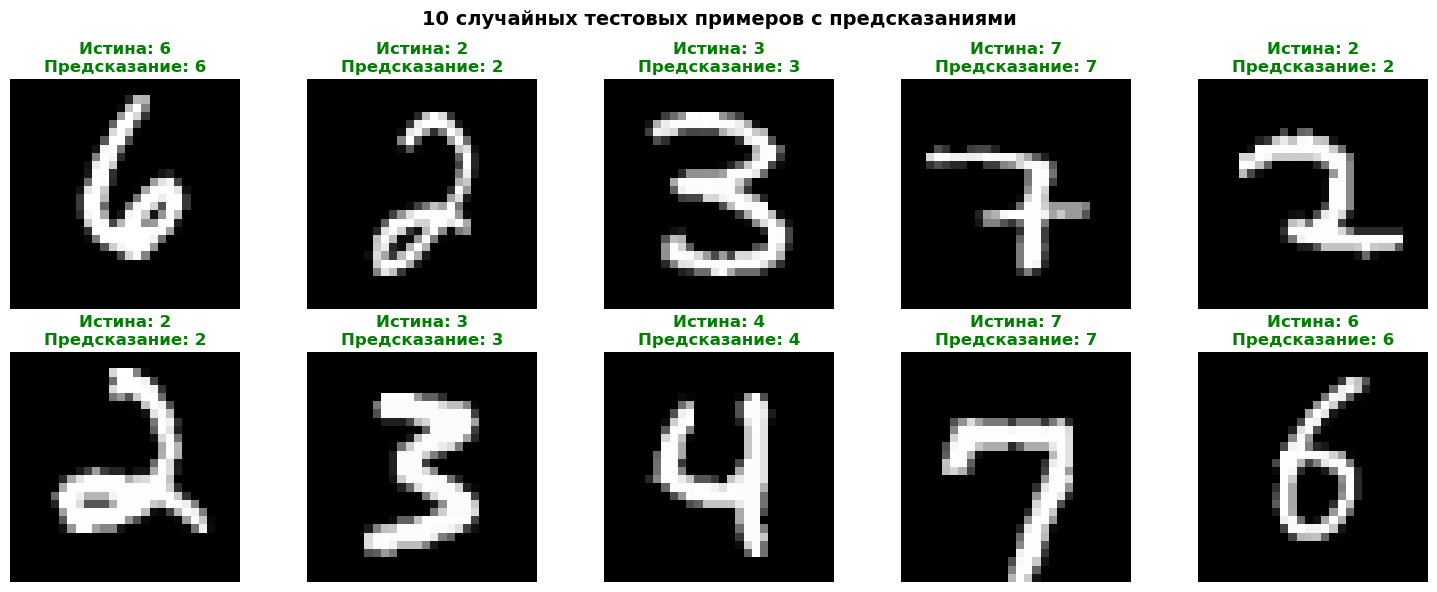

In [16]:
np.random.seed(42)
random_indices = np.random.choice(len(test_dataset), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('10 случайных тестовых примеров с предсказаниями', fontsize=14, fontweight='bold')

model.eval()
with torch.no_grad():
    for idx, ax in enumerate(axes.flat):
        sample_idx = random_indices[idx]
        image, true_label = test_dataset[sample_idx]
        
        image_tensor = image.unsqueeze(0).to(device)
        output = model(image_tensor)
        pred_label = output.argmax(dim=1).item()
        
        image_np = image.squeeze().cpu().numpy()
        ax.imshow(image_np, cmap='gray')
        ax.axis('off')
        
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'Истина: {true_label}\nПредсказание: {pred_label}', 
                    color=color, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Исследования различных параметров

Будем исследовать следующие параметры:
1. Количество эпох
2. Оптимизаторы (SGD и Adam) и learning rate
3. Конфигурация сверточной архитектуры (количество слоев, размер ядра)
4. Размер батчей

### 6.1. Влияние количества эпох

Обучение на 5 эпохах


Эпоха 1/5: 100%|██████████| 938/938 [00:14<00:00, 64.64it/s, loss=0.00396]


Эпоха 1/5 Loss: 0.1540


Эпоха 2/5: 100%|██████████| 938/938 [00:14<00:00, 64.82it/s, loss=0.00184] 


Эпоха 2/5 Loss: 0.0431


...

Эпоха 18/20 Loss: 0.0036


Эпоха 19/20: 100%|██████████| 938/938 [00:14<00:00, 65.01it/s, loss=5.66e-5] 


Эпоха 19/20 Loss: 0.0065


Эпоха 20/20: 100%|██████████| 938/938 [00:14<00:00, 66.09it/s, loss=1.04e-5] 


Эпоха 20/20 Loss: 0.0056
Accuracy: 0.9919, F1: 0.9919, Final Loss: 0.0056


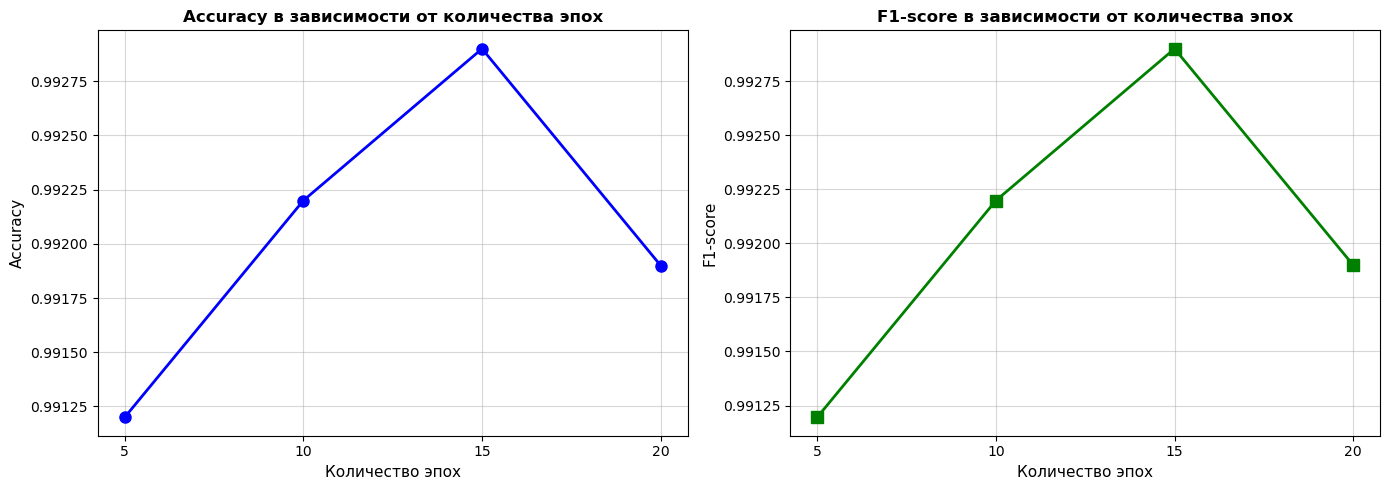


Результаты исследования количества эпох:
5 эпох: Accuracy=0.9912, F1=0.9912
10 эпох: Accuracy=0.9922, F1=0.9922
15 эпох: Accuracy=0.9929, F1=0.9929
20 эпох: Accuracy=0.9919, F1=0.9919


In [17]:
epochs_to_test = [5, 10, 15, 20]
epoch_results = {}

for num_epochs in epochs_to_test:
    print(f"Обучение на {num_epochs} эпохах")
    
    model = CNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    losses = train_model(model, train_loader, optimizer, criterion, num_epochs, device)
    accuracy, f1, _, _ = evaluate_model(model, test_loader, device)
    
    epoch_results[num_epochs] = {
        'accuracy': accuracy,
        'f1': f1,
        'final_loss': losses[-1]
    }
    
    print(f"Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Final Loss: {losses[-1]:.4f}")

epochs_list = list(epoch_results.keys())
accuracies = [epoch_results[e]['accuracy'] for e in epochs_list]
f1_scores = [epoch_results[e]['f1'] for e in epochs_list]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_list, accuracies, marker='o', linewidth=2, markersize=8, color='blue')
ax1.set_title('Accuracy в зависимости от количества эпох', fontsize=12, fontweight='bold')
ax1.set_xlabel('Количество эпох', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.grid(True, alpha=0.5)
ax1.set_xticks(epochs_list)

ax2.plot(epochs_list, f1_scores, marker='s', linewidth=2, markersize=8, color='green')
ax2.set_title('F1-score в зависимости от количества эпох', fontsize=12, fontweight='bold')
ax2.set_xlabel('Количество эпох', fontsize=11)
ax2.set_ylabel('F1-score', fontsize=11)
ax2.grid(True, alpha=0.5)
ax2.set_xticks(epochs_list)

plt.tight_layout()
plt.show()

print("\nРезультаты исследования количества эпох:")
for epochs, results in epoch_results.items():
    print(f"{epochs} эпох: Accuracy={results['accuracy']:.4f}, F1={results['f1']:.4f}")

### 6.2. Оптимизаторы (SGD и Adam) и learning rate

Обучение с Adam, lr=0.001


Эпоха 1/10: 100%|██████████| 938/938 [00:14<00:00, 64.18it/s, loss=0.0173] 


Эпоха 1/10 Loss: 0.1514


Эпоха 2/10: 100%|██████████| 938/938 [00:14<00:00, 65.93it/s, loss=0.0102]  


Эпоха 2/10 Loss: 0.0431


...

Эпоха 8/10 Loss: 0.0957


Эпоха 9/10: 100%|██████████| 938/938 [00:13<00:00, 70.12it/s, loss=0.0697]  


Эпоха 9/10 Loss: 0.2375


Эпоха 10/10: 100%|██████████| 938/938 [00:13<00:00, 69.30it/s, loss=2.29] 


Эпоха 10/10 Loss: 1.4757
Accuracy: 0.1135, F1: 0.0231


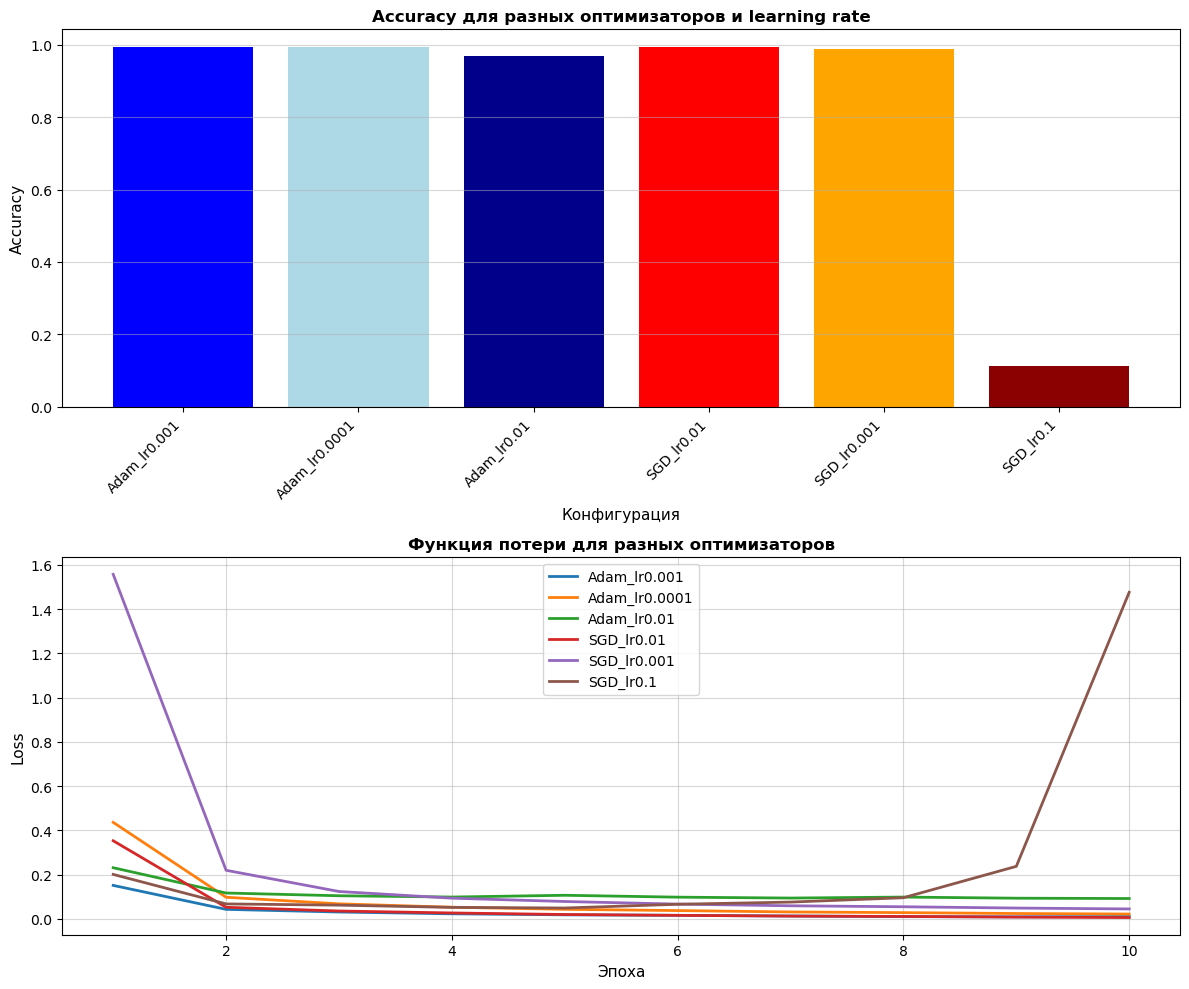


Результаты исследования оптимизаторов:
Adam_lr0.001: Accuracy=0.9924, F1=0.9924
Adam_lr0.0001: Accuracy=0.9922, F1=0.9922
Adam_lr0.01: Accuracy=0.9690, F1=0.9691
SGD_lr0.01: Accuracy=0.9925, F1=0.9925
SGD_lr0.001: Accuracy=0.9871, F1=0.9871
SGD_lr0.1: Accuracy=0.1135, F1=0.0231


In [18]:
optimizer_configs = [
    ('Adam', 0.001),
    ('Adam', 0.0001),
    ('Adam', 0.01),
    ('SGD', 0.01),
    ('SGD', 0.001),
    ('SGD', 0.1),
]

optimizer_results = {}
num_epochs = 10

for opt_name, lr in optimizer_configs:
    print(f"Обучение с {opt_name}, lr={lr}")
    
    model = CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    
    if opt_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    losses = train_model(model, train_loader, optimizer, criterion, num_epochs, device)
    accuracy, f1, _, _ = evaluate_model(model, test_loader, device)
    
    key = f"{opt_name}_lr{lr}"
    optimizer_results[key] = {
        'accuracy': accuracy,
        'f1': f1,
        'final_loss': losses[-1],
        'losses': losses
    }
    
    print(f"Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

keys = list(optimizer_results.keys())
accuracies = [optimizer_results[k]['accuracy'] for k in keys]
axes[0].bar(range(len(keys)), accuracies, color=['blue', 'lightblue', 'darkblue', 'red', 'orange', 'darkred'])
axes[0].set_title('Accuracy для разных оптимизаторов и learning rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Конфигурация', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_xticks(range(len(keys)))
axes[0].set_xticklabels(keys, rotation=45, ha='right')
axes[0].grid(True, alpha=0.5, axis='y')

axes[1].set_title('Функция потери для разных оптимизаторов', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Эпоха', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
for key, results in optimizer_results.items():
    axes[1].plot(range(1, num_epochs + 1), results['losses'], label=key, linewidth=2)
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

print("\nРезультаты исследования оптимизаторов:")
for key, results in optimizer_results.items():
    print(f"{key}: Accuracy={results['accuracy']:.4f}, F1={results['f1']:.4f}")

### 6.3. Исследование сверточной архитектуры

Обучение архитектуры: 2 слоя


Эпоха 1/10: 100%|██████████| 938/938 [00:14<00:00, 66.32it/s, loss=0.0465] 


Эпоха 1/10 Loss: 0.1405


Эпоха 2/10: 100%|██████████| 938/938 [00:13<00:00, 70.57it/s, loss=0.00165]


Эпоха 2/10 Loss: 0.0413


...

Эпоха 8/10 Loss: 0.0116


Эпоха 9/10: 100%|██████████| 938/938 [00:15<00:00, 59.85it/s, loss=0.000142]


Эпоха 9/10 Loss: 0.0105


Эпоха 10/10: 100%|██████████| 938/938 [00:15<00:00, 61.39it/s, loss=6.39e-5] 


Эпоха 10/10 Loss: 0.0087
Accuracy: 0.9931, F1: 0.9931


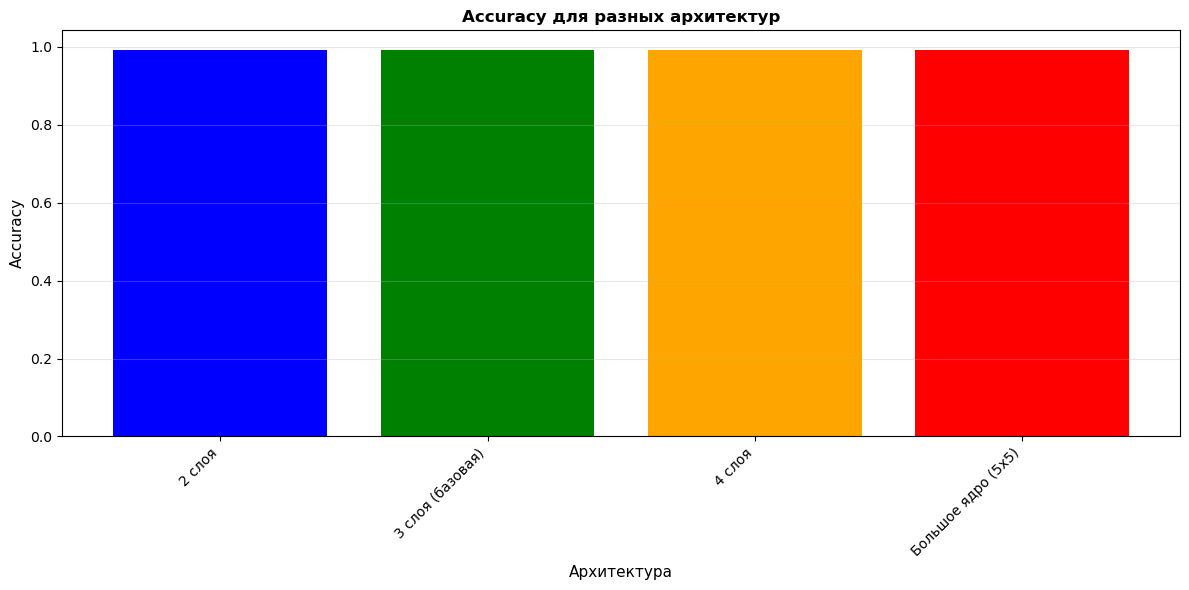


Результаты исследования архитектур:
2 слоя: Accuracy=0.9921, F1=0.9921
3 слоя (базовая): Accuracy=0.9922, F1=0.9922
4 слоя: Accuracy=0.9925, F1=0.9925
Большое ядро (5x5): Accuracy=0.9931, F1=0.9931


In [19]:
class CNN_2Layers(nn.Module):
    def __init__(self):
        super(CNN_2Layers, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class CNN_4Layers(nn.Module):
    def __init__(self):
        super(CNN_4Layers, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(256 * 1 * 1, 256)
        self.fc2 = nn.Linear(256, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = F.relu(self.conv4(x))
        x = self.pool4(x)
        x = x.view(-1, 256 * 1 * 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class CNN_LargeKernel(nn.Module):
    def __init__(self):
        super(CNN_LargeKernel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

architectures = {
    '2 слоя': CNN_2Layers,
    '3 слоя (базовая)': CNN,
    '4 слоя': CNN_4Layers,
    'Большое ядро (5x5)': CNN_LargeKernel
}

architecture_results = {}
num_epochs = 10

for arch_name, arch_class in architectures.items():
    print(f"Обучение архитектуры: {arch_name}")

    model = arch_class().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    losses = train_model(model, train_loader, optimizer, criterion, num_epochs, device)
    accuracy, f1, _, _ = evaluate_model(model, test_loader, device)
    
    architecture_results[arch_name] = {
        'accuracy': accuracy,
        'f1': f1,
        'final_loss': losses[-1]
    }
    
    print(f"Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

arch_names = list(architecture_results.keys())
arch_accuracies = [architecture_results[a]['accuracy'] for a in arch_names]

plt.figure(figsize=(12, 6))
plt.bar(arch_names, arch_accuracies, color=['blue', 'green', 'orange', 'red'])
plt.title('Accuracy для разных архитектур', fontsize=12, fontweight='bold')
plt.xlabel('Архитектура', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nРезультаты исследования архитектур:")
for arch_name, results in architecture_results.items():
    print(f"{arch_name}: Accuracy={results['accuracy']:.4f}, F1={results['f1']:.4f}")

### 6.4. Исследование влияния размера батчей

Обучение с batch_size=32


Эпоха 1/10: 100%|██████████| 1875/1875 [00:23<00:00, 81.42it/s, loss=0.00818] 


Эпоха 1/10 Loss: 0.1320


Эпоха 2/10: 100%|██████████| 1875/1875 [00:22<00:00, 82.70it/s, loss=0.00165] 


Эпоха 2/10 Loss: 0.0415


...

Эпоха 8/10 Loss: 0.0117


Эпоха 9/10: 100%|██████████| 235/235 [00:06<00:00, 33.67it/s, loss=0.000853]


Эпоха 9/10 Loss: 0.0104


Эпоха 10/10: 100%|██████████| 235/235 [00:07<00:00, 33.11it/s, loss=0.0159]  


Эпоха 10/10 Loss: 0.0094
Accuracy: 0.9910, F1: 0.9910


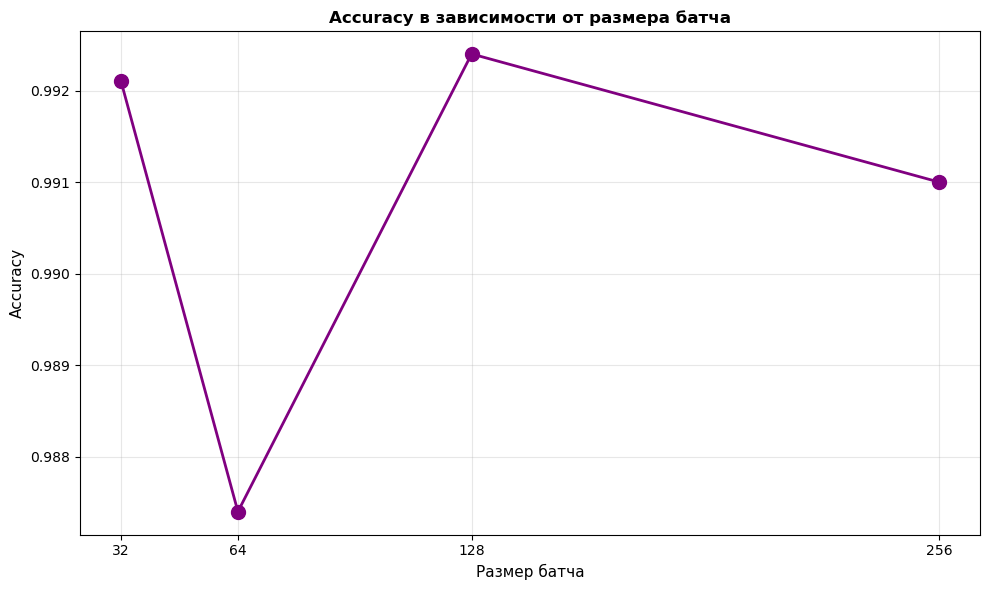


Результаты исследования размера батчей:
Batch size 32: Accuracy=0.9921, F1=0.9921
Batch size 64: Accuracy=0.9874, F1=0.9874
Batch size 128: Accuracy=0.9924, F1=0.9924
Batch size 256: Accuracy=0.9910, F1=0.9910


In [20]:
batch_sizes = [32, 64, 128, 256]
batch_results = {}
num_epochs = 10

for batch_size in batch_sizes:
    print(f"Обучение с batch_size={batch_size}")
    
    train_loader_batch = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )
    
    model = CNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    losses = train_model(model, train_loader_batch, optimizer, criterion, num_epochs, device)
    accuracy, f1, _, _ = evaluate_model(model, test_loader, device)
    
    batch_results[batch_size] = {
        'accuracy': accuracy,
        'f1': f1,
        'final_loss': losses[-1]
    }
    
    print(f"Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

batch_sizes_list = list(batch_results.keys())
batch_accuracies = [batch_results[b]['accuracy'] for b in batch_sizes_list]

plt.figure(figsize=(10, 6))
plt.plot(batch_sizes_list, batch_accuracies, marker='o', linewidth=2, markersize=10, color='purple')
plt.title('Accuracy в зависимости от размера батча', fontsize=12, fontweight='bold')
plt.xlabel('Размер батча', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(batch_sizes_list)
plt.tight_layout()
plt.show()

print("\nРезультаты исследования размера батчей:")
for batch_size, results in batch_results.items():
    print(f"Batch size {batch_size}: Accuracy={results['accuracy']:.4f}, F1={results['f1']:.4f}")


## 7. Выводы из исследования

### Анализ результатов:

**1. Количество эпох:**
- Обучение на **15 эпохах** показывает наилучший результат
- При меньшем количестве эпох модель не успевает полностью обучиться
- При большем количестве эпох точность и f1 падают даже чуть ниже уровня 10 эпох

**2. Оптимизаторы (SGD и Adam) и learning rate:**
- **Adam с lr=0.001** показал наилучшие результаты
- Adam в целом работает лучше, чем SGD для данной задачи
- Слишком большой learning rate (0.1) приводит к нестабильному обучению (на SGD вообще катастрофа)
- Слишком маленький learning rate (0.0001) немного замедляет обучение

**3. Конфигурация сверточной архитектуры:**
- Хоть и различия между разными архитектурами в нашей выборке минимальны, однако видно, что **4 слоя** и **ядро 5х5** оказались более точны, чем архитектура на 3 слоях и ядре 3х3

**4. Размер батчей:**
- Изначально выбранный размер батча 64 оказался наихудшим по точности
- Оптимальным размером батча в этой модели будет **128**, после и до этого порога точность теряется

### Эмпирически выявленная наилучшая конфигурация модели:

- **Архитектура:** 4 сверточных слоя с ядром 5x5
- **Оптимизатор:** Adam с learning rate = 0.001
- **Batch size:** 128
- **Количество эпох:** 15
- **Достигнутая точность (тест ниже):** >99%


## 8. Тест оптимальной конфигурации (дополнительно для проверки теории):


Начало обучения оптимальной модели:
- Архитектура: 4 сверточных слоя с ядром 5x5
- Оптимизатор: Adam с learning rate = 0.001
- Batch size: 128
- Количество эпох: 15


Эпоха 1/15: 100%|██████████| 469/469 [00:15<00:00, 30.41it/s, loss=0.0634]


Эпоха 1/15 Loss: 0.1990


Эпоха 2/15: 100%|██████████| 469/469 [00:14<00:00, 32.27it/s, loss=0.0325] 


Эпоха 2/15 Loss: 0.0450


...

Эпоха 13/15 Loss: 0.0102


Эпоха 14/15: 100%|██████████| 469/469 [00:14<00:00, 33.03it/s, loss=0.00104] 


Эпоха 14/15 Loss: 0.0087


Эпоха 15/15: 100%|██████████| 469/469 [00:14<00:00, 32.82it/s, loss=0.000153]


Эпоха 15/15 Loss: 0.0076
Оценка модели на тестовой выборке:

 РЕЗУЛЬТАТЫ:
   Accuracy: 0.9909 (99.09%)
   F1-score: 0.9909
   Final Loss: 0.0076


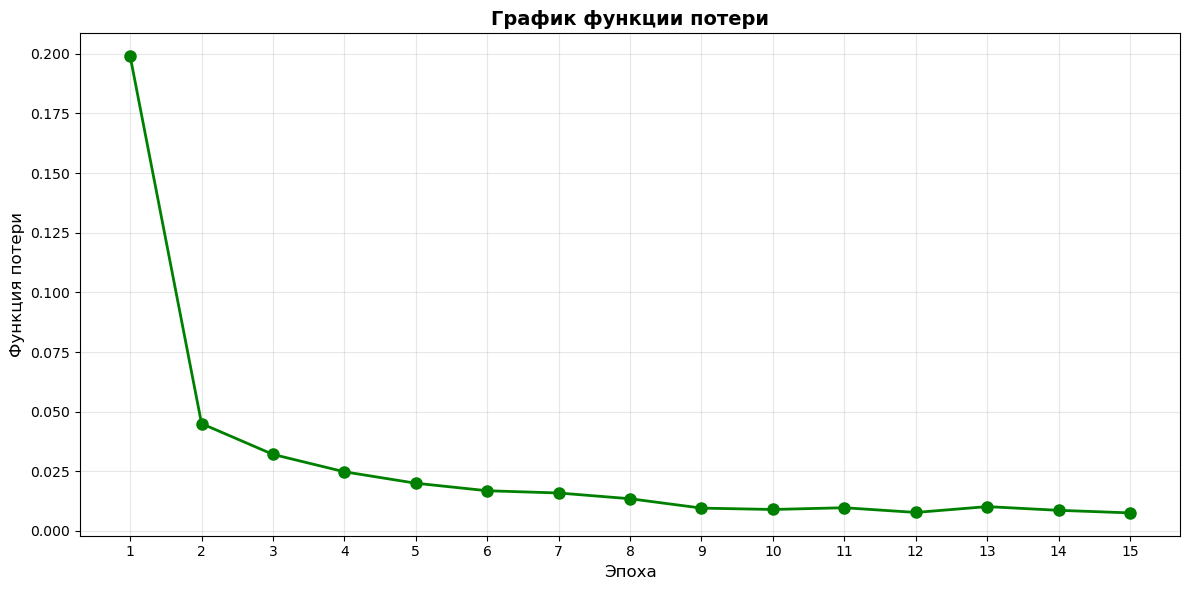

In [21]:
class CNN_4Layers_5x5(nn.Module):
    def __init__(self):
        super(CNN_4Layers_5x5, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=5, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(256 * 1 * 1, 256)
        self.fc2 = nn.Linear(256, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        
        x = F.relu(self.conv4(x))
        x = self.pool4(x)
        
        x = x.view(-1, 256 * 1 * 1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

optimal_batch_size = 128
train_loader_optimal = DataLoader(
    train_dataset,
    batch_size=optimal_batch_size,
    shuffle=True
)

test_loader_optimal = DataLoader(
    test_dataset,
    batch_size=optimal_batch_size,
    shuffle=False
)

model_optimal = CNN_4Layers_5x5().to(device)

criterion = nn.CrossEntropyLoss()
optimizer_optimal = torch.optim.Adam(model_optimal.parameters(), lr=0.001)
num_epochs_optimal = 15

print(f"\nНачало обучения оптимальной модели:")
print(f"- Архитектура: 4 сверточных слоя с ядром 5x5")
print(f"- Оптимизатор: Adam с learning rate = 0.001")
print(f"- Batch size: {optimal_batch_size}")
print(f"- Количество эпох: {num_epochs_optimal}")

losses_optimal = train_model(
    model_optimal, 
    train_loader_optimal, 
    optimizer_optimal, 
    criterion, 
    num_epochs_optimal, 
    device
)

print("Оценка модели на тестовой выборке:")
accuracy_optimal, f1_optimal, predictions_optimal, true_labels_optimal = evaluate_model(
    model_optimal, 
    test_loader_optimal, 
    device
)

print(f"\n РЕЗУЛЬТАТЫ:")
print(f"   Accuracy: {accuracy_optimal:.4f} ({accuracy_optimal*100:.2f}%)")
print(f"   F1-score: {f1_optimal:.4f}")
print(f"   Final Loss: {losses_optimal[-1]:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs_optimal + 1), losses_optimal, marker='o', linewidth=2, markersize=8, color='green')
plt.title('График функции потери', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Функция потери', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, num_epochs_optimal + 1))
plt.tight_layout()
plt.show()

### P.S. к тесту оптимальной конфигурации:

При попытке соединить все лучшие настройки из экспериментов результат не оказался наилучшим, скорее остался просто +- таким же, как говорится, в пределах погрешности. 

Хотя, наверняка, есть более оптимальная конфигурация, как минимум с точки зрения соотношения затраченного на обучение времени и точности модели, так, даже с исходной конфигурацией и архитектурой разница во времени обучения составляет 1 минуту не в пользу "оптимальной" (что при общем времени обучения 3 минуты -- довольно существенно), а результаты, в свою очередь, вышли примерно одинаковые. 

Для выявления идеальных настроек нужно провести ещё больше экспериментов с иными комбинациями гиперпараметров.